In [17]:
# verify the rule from XX-optimal-synthesis Lemma 5.2
from qutip import sigmax, sigmaz, tensor, sigmay
import numpy as np
from weylchamber import c1c2c3

In [18]:
XX = tensor(sigmax(), sigmax())
YY = tensor(sigmay(), sigmay())
ZZ = tensor(sigmaz(), sigmaz())


def canonical_gate(x, y, z):
    return (-1j * (x * XX + y * YY + z * ZZ)).expm()


def weyl_c(gate):
    return np.array(c1c2c3(gate)) * np.pi / 2


def rz(phi):
    return (-1j * phi * sigmaz()).expm()


def ry(phi):
    return (-1j * phi * sigmay()).expm()


def cot(x):
    return 1 / np.tan(x)


def csc(x):
    return 1 / np.sin(x)

In [19]:
# def solve_d_e_from_lemma(a1, a2, b1, b2, beta):
#     x1 = cot(2 * (a1 - a2)) * cot(2 * beta) - np.cos(2 * (b1 - b2)) * csc(
#         2 * (a1 - a2)
#     ) * csc(2 * beta)
#     x2 = cot(2 * (a1 + a2)) * cot(2 * beta) - np.cos(2 * (b1 + b2)) * csc(
#         2 * (a1 + a2)
#     ) * csc(2 * beta)

#     y1 = np.arccos(x1)
#     y2 = np.arccos(x2)

#     d = (y1 + y2) / 4
#     e = (y1 - y2) / 4
#     return d, e


def solve_d_e_from_lemma(a1, a2, b1, b2, beta):
    num1 = (
        -2 * np.cos(2 * b1 - 2 * b2)
        + np.cos(2 * a1 - 2 * a2 - 2 * beta)
        + np.cos(2 * a1 - 2 * a2 + 2 * beta)
    )
    den1 = np.cos(2 * a1 - 2 * a2 - 2 * beta) - np.cos(2 * a1 - 2 * a2 + 2 * beta)
    x1 = num1 / den1

    num2 = (
        -2 * np.cos(2 * b1 + 2 * b2)
        + np.cos(2 * a1 + 2 * a2 - 2 * beta)
        + np.cos(2 * a1 + 2 * a2 + 2 * beta)
    )
    den2 = np.cos(2 * a1 + 2 * a2 - 2 * beta) - np.cos(2 * a1 + 2 * a2 + 2 * beta)
    x2 = num2 / den2

    y1 = np.arccos(x1)
    y2 = np.arccos(x2)

    d = (y1 + y2) / 4
    e = (y1 - y2) / 4

    return d, e


def solve_d_e_modified(a1, a2, b1, b2, alpha, beta):
    num1 = (
        2 * np.cos(2 * b1 - 2 * b2)
        - np.cos(2 * a1 - 2 * a2 + 2 * alpha - 2 * beta)
        - np.cos(2 * a1 - 2 * a2 - 2 * alpha + 2 * beta)
    )
    den1 = np.cos(2 * a1 - 2 * a2 + 2 * alpha - 2 * beta) - np.cos(
        2 * a1 - 2 * a2 - 2 * alpha + 2 * beta
    )
    x1 = num1 / den1

    num2 = (
        -2 * np.cos(2 * b1 + 2 * b2)
        + np.cos(2 * a1 + 2 * a2 - 2 * alpha - 2 * beta)
        + np.cos(2 * a1 + 2 * a2 + 2 * alpha + 2 * beta)
    )
    den2 = np.cos(2 * a1 + 2 * a2 - 2 * alpha - 2 * beta) - np.cos(
        2 * a1 + 2 * a2 + 2 * alpha + 2 * beta
    )
    x2 = num2 / den2

    y1 = np.arccos(x1)
    y2 = np.arccos(x2)

    d = (y1 + y2) / 4
    e = (y1 - y2) / 4

    return d, e

In [20]:
# try random values between 0 and pi/2 to guarantee a solution
a1, a2, a3 = np.random.rand(3) * np.pi / 2
# should be a1 > a2 > a3, use sort
a1, a2, a3 = sorted([a1, a2, a3], reverse=True)
alpha, beta = np.random.rand(2) * np.pi / 2
# enforce alpha > beta to avoid negative angles in the solution
if alpha < beta:
    alpha, beta = beta, alpha
d, e = np.random.rand(2) * np.pi / 2

# enforce a3 = 0 (for now)
a3 = 0

NOTE, this doesn't work on all inputs! that indicates to me there are some periodic features of the trig that give the wrong solution if not handled carefully throughout(?) but the fact that it works perfectly on some inputs must mean it is mostly right.

In [44]:
constructed = (
    canonical_gate(beta, 0, 0) @ tensor(rz(d), rz(e)) @ canonical_gate(a1, a2, a3)
)
target = canonical_gate(*weyl_c(constructed))
b1, b2, b3 = weyl_c(target)
print(b1, b2, b3)

0.8750188953891922 0.11390392373507846 0.0


In [59]:
a1, a2, a3 = np.pi / 4, 0, 0
alpha, beta = 0, np.pi / 8
b1, b2, b3 = np.pi / 4, np.pi / 8, 0

In [ ]:
d, e = solve_d_e_from_lemma(a1, a2, b1, b2, beta)
constructed = (
    canonical_gate(beta, 0, 0) @ tensor(rz(d), rz(e)) @ canonical_gate(a1, a2, a3)
)
weyl_c(constructed)

array([0.78539816, 0.39269908, 0.        ])

In [62]:
tensor(rz(d), rz(e))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[2.23711432e-17-1.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 1.00000000e+00+2.23711432e-17j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  1.00000000e+00-2.23711432e-17j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 2.23711432e-17+1.00000000e+00j]]

In [46]:
# check that the modified solution reduces to the original lemma solution
print(solve_d_e_from_lemma(a1, a2, b1, b2, beta))
print(solve_d_e_modified(a1, a2, b1, b2, beta, 0))

(0.6540127156125274, 0.16574059424337886)
(0.6540127156125274, 0.16574059424337886)


Try again with the XY modification

In [47]:
constructed = (
    canonical_gate(alpha, beta, 0) @ tensor(rz(d), rz(e)) @ canonical_gate(a1, a2, a3)
)
target = canonical_gate(*weyl_c(constructed))
b1, b2, b3 = weyl_c(target)
print(b1, b2, b3)

0.8993020871325267 0.08962073199174388 0.0


In [48]:
d, e = solve_d_e_modified(a1, a2, b1, b2, alpha, beta)
constructed = (
    canonical_gate(alpha, beta, 0) @ tensor(rz(d), rz(e)) @ canonical_gate(a1, a2, 0)
)
weyl_c(constructed)

array([0.89930209, 0.08962073, 0.        ])

Important question. Is XX.YY.(z z).XX.YY really same as XX.YY.(u u).XX.YY? No :(

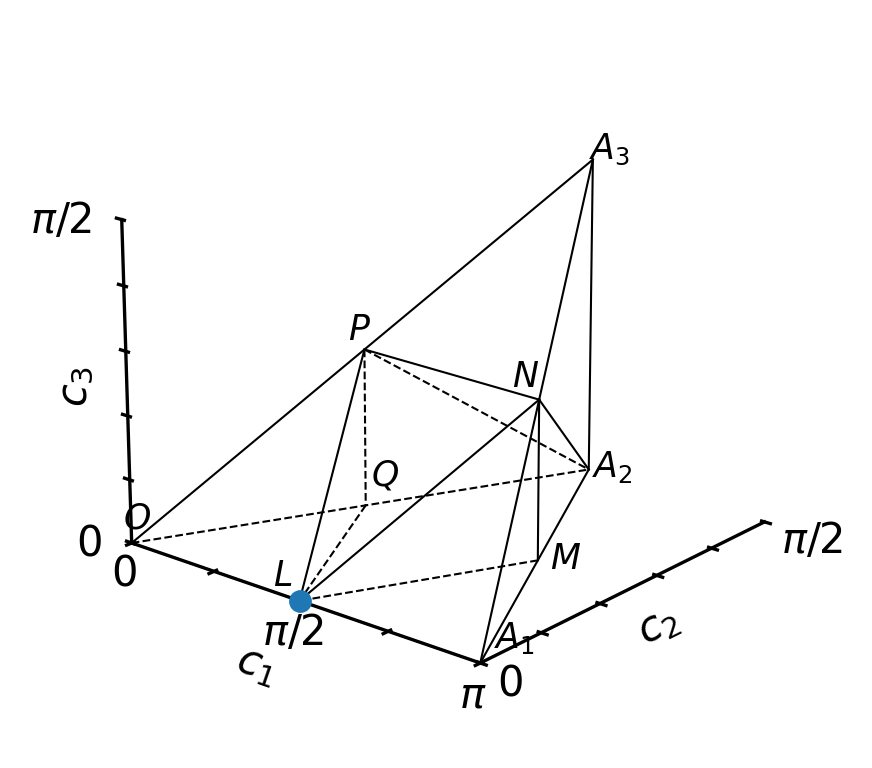

In [ ]:
from weylchamber import WeylChamber, c1c2c3

point_cloud1 = []
for i in range(4_096):
    a1, a2, a3 = 0, np.pi / 4, 0
    b1, b2, b3 = 0, 0, np.pi / 8
    # b1, b2 = np.random.rand(2) * np.pi
    ze, zf = np.random.rand(2) * np.pi
    point_cloud1.append(
        c1c2c3(
            canonical_gate(a1, a2, 0)
            @ tensor(rz(ze), rz(zf))
            @ canonical_gate(b1, b2, 0)
        )
    )

w = WeylChamber()
for point in point_cloud1:
    w.add_point(*point)
w.plot()

In [203]:
a1, a2, a3 = 0, np.pi / 4, 0
b1, b2, b3 = 0, 0, np.pi / 8
# b1, b2 = np.random.rand(2) * np.pi
ze, zf = np.random.rand(2) * np.pi

canonical_gate(a1, a2, a3) @ tensor(rz(ze), rz(zf)) @ canonical_gate(b1, b2, b3)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.56209396-0.42901093j  0.        +0.j          0.        +0.j
  -0.70081699-0.09410392j]
 [ 0.        +0.j          0.03641584-0.70616846j  0.52508639+0.47358662j
   0.        +0.j        ]
 [ 0.        +0.j         -0.70616846-0.03641584j -0.47358662+0.52508639j
   0.        +0.j        ]
 [ 0.42901093-0.56209396j  0.        +0.j          0.        +0.j
  -0.09410392+0.70081699j]]

In [208]:
(canonical_gate(b1, b2, b3) @ tensor(rz(ze), rz(zf)) @ canonical_gate(a1, a2, a3)).dag()

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.56209396+0.42901093j  0.        -0.j          0.        -0.j
  -0.70081699+0.09410392j]
 [ 0.        -0.j          0.03641584+0.70616846j  0.52508639-0.47358662j
   0.        -0.j        ]
 [ 0.        -0.j         -0.70616846+0.03641584j -0.47358662-0.52508639j
   0.        -0.j        ]
 [ 0.42901093+0.56209396j  0.        -0.j          0.        -0.j
  -0.09410392-0.70081699j]]

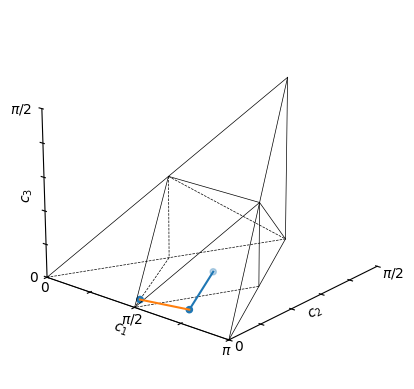

[(0.5, 0.25, 0.0), (0.68633418, 0.0632536, 0.0), (0.46241312, 0.03738064, 0.0), (0.46241312, 0.03738064, 0.0)]


In [198]:
import matplotlib.pyplot as plt
from qiskit.circuit.library import U3Gate
from qutip import Qobj
from weylchamber import WeylChamber

# Initial CAN + local rotations
a1, a2, a3 = np.pi / 4, np.pi / 8, 0
b1, b2, b3 = np.pi / 4, np.pi / 8, 0

# random parameters for local rotations
theta1, phi1, lam1 = np.random.rand(3) * np.pi / 2
theta2, phi2, lam2 = np.random.rand(3) * np.pi / 2
L1 = Qobj(U3Gate(theta1, phi1, lam1).to_matrix())
L2 = Qobj(U3Gate(theta2, phi2, lam2).to_matrix())
L = tensor(L1, L2)
L = tensor(rz(theta1), rz(theta2))

base = canonical_gate(a1, a2, a3) @ L

# Step 0: Apply the base gate
# This is the initial gate that we will apply the canonical gates to
step0 = base
inv0 = c1c2c3(step0)

# Step 1: Apply XX(b1)
step1 = base @ canonical_gate(b1, 0, 0)
inv1 = c1c2c3(step1)

# Step 2: Apply YY(b2)
step2 = base @ canonical_gate(b1, b2, 0)
inv2 = c1c2c3(step2)

# Step 3: Apply ZZ(b3)
step3 = base @ canonical_gate(b1, b2, b3)
inv3 = c1c2c3(step3)


# Suppose you already have these points:
points_on_surface = [inv0, inv1, inv2, inv3]  # Each point is a 3-tuple

# Set up plot
w = WeylChamber()
w.labels = {}
ax = plt.subplot(111, projection="3d", computed_zorder=False)
w.render(ax)

# Scatter the points
w.ax.scatter3D(*zip(*points_on_surface), zorder=-1)

# Connect the points with a line in order from inv0 to inv1, then inv1 to inv2, and finally inv2 to inv3
segments = [
    (inv0, inv1),
    (inv1, inv2),
    (inv2, inv3),
]
for origin, end in segments:
    w._draw_line(ax, origin, end)

plt.show()
print(points_on_surface)